In [75]:
using Statistics
using CairoMakie

### Assume motion is less and less instantaneous

Start from 5 steps of 200nm

In [110]:
# Move 1 um in 0.2 s (corresponds to 5 200nm steps with 40ms dwell time)
total_time = 0.2 #s, 200ms
step_sizes = [0.2, 0.1, 0.05, 0.04, 0.02, 0.01, 0.005, 0.002, 0.0015, 0.001 ] #um
println(step_sizes*1000, " nm")
n_steps = 1 ./ step_sizes
println("N steps: ", n_steps)
# x = 0:n_steps:1
dt = 0.2 ./ n_steps
println("dt: ", dt, " s")
dims = 2 # assume 2D motion for now

diff_coeffs = step_sizes.^2 ./ (2*dims*dt)
println("Diff coeffs: ", diff_coeffs, " um^2/s")

[200.0, 100.0, 50.0, 40.0, 20.0, 10.0, 5.0, 2.0, 1.5, 1.0] nm
N steps: [5.0, 10.0, 20.0, 25.0, 50.0, 100.0, 200.0, 500.0, 666.6666666666666, 1000.0]
dt: [0.04, 0.02, 0.01, 0.008, 0.004, 0.002, 0.001, 0.0004, 0.00030000000000000003, 0.0002] s
Diff coeffs: [0.25000000000000006, 0.12500000000000003, 0.06250000000000001, 0.05, 0.025, 0.0125, 0.00625, 0.0024999999999999996, 0.001875, 0.0012499999999999998] um^2/s


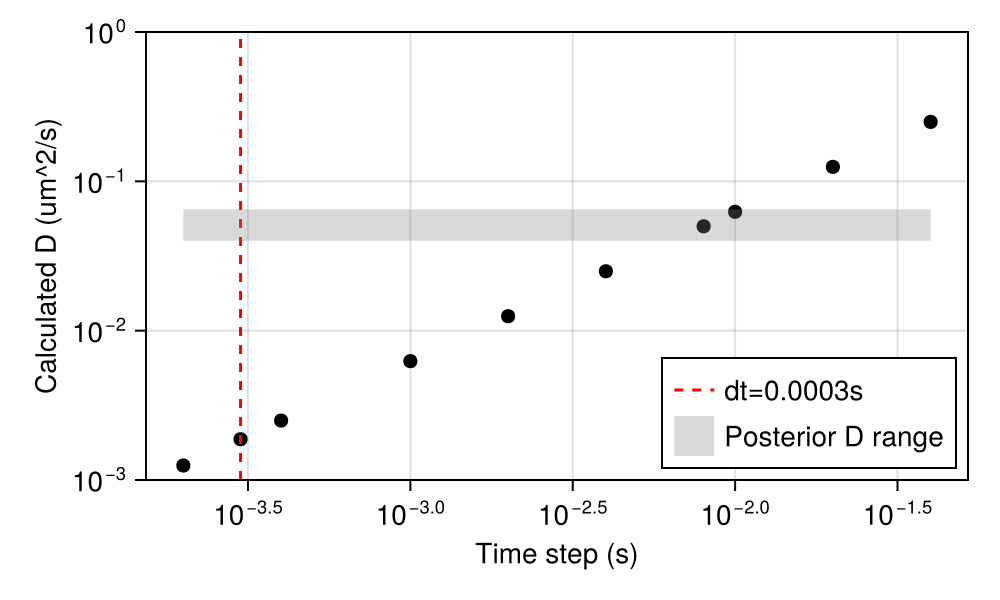

CairoMakie.Screen{IMAGE}


In [114]:
# 0.04 to 0.065
fig = Figure(size=(500,300))
ax = Axis(
    fig[1,1],
    xlabel = "Time step (s)",
    ylabel = "Calculated D (um^2/s)",
    xscale = log10,
    yscale= log10
)
scatter!(ax, dt, diff_coeffs, color=:black, markersize=10)
vlines!(ax, 0.0003, color=:red, linestyle=:dash, label="dt=0.0003s")
band!(ax, dt, 0.04, 0.065, color=:gray, alpha=0.3, label="Posterior D range")
ylims!(ax, 10^-3, 1)
axislegend(ax, position=:rb)
display(fig)

### Assume 200nm movement takes one step, and all other steps are $\delta x$

In the ideal case $\delta x$ is 0, but if it is of order of the localization uncertainty it can change the estimate of D significantly

In [116]:
d = 0.2 # um
# n_rest = Int.(ceil((n_steps .- 5)))
# rest_dx = 0.0
# rest_dx = 0.01 #um
dx_vals = [1, 5, 7, 10, 20, 40] #nm

dims = 2
println("'Rest' steps have dx movement of ", rest_dx, " um")
# diff_coeffs = []
diff_coeffs = zeros(length(dx_vals), length(dt))
# for (nr, dt_i) in zip(n_rest, dt)
for (j, rest_dx) in enumerate(dx_vals)
    rest_dx = rest_dx / 1000 # convert to um
    for (i, dt_i) in enumerate(dt)
        nr = Int(ceil(n_steps[i] - 5))
        println("n rest: ", nr, ", dt: ", dt_i, " s", " n_steps: ", nr+5)
        displacements = vcat(fill(d^2, 5), fill(rest_dx^2, nr))
        # print(displacements)
        msd = mean(displacements)
        diff_coeff = msd / (2*dims*dt_i)
        # println("MSD: ", msd)
        println("Diff coeff: ", diff_coeff)
        # push!(diff_coeffs, diff_coeff)
        diff_coeffs[j, i] = diff_coeff
    end
end

'Rest' steps have dx movement of 0.04 um
n rest: 0, dt: 0.04 s n_steps: 5
Diff coeff: 0.25000000000000006
n rest: 5, dt: 0.02 s n_steps: 10
Diff coeff: 0.25000625000000004
n rest: 15, dt: 0.01 s n_steps: 20
Diff coeff: 0.25001875000000007
n rest: 20, dt: 0.008 s n_steps: 25
Diff coeff: 0.25002500000000005
n rest: 45, dt: 0.004 s n_steps: 50
Diff coeff: 0.2500562500000001
n rest: 95, dt: 0.002 s n_steps: 100
Diff coeff: 0.2501187500000001
n rest: 195, dt: 0.001 s n_steps: 200
Diff coeff: 0.25024375000000004
n rest: 495, dt: 0.0004 s n_steps: 500
Diff coeff: 0.25061875000000017
n rest: 662, dt: 0.00030000000000000003 s n_steps: 667
Diff coeff: 0.2507021489255374
n rest: 995, dt: 0.0002 s n_steps: 1000
Diff coeff: 0.25124375000000027
n rest: 0, dt: 0.04 s n_steps: 5
Diff coeff: 0.25000000000000006
n rest: 5, dt: 0.02 s n_steps: 10
Diff coeff: 0.25015625
n rest: 15, dt: 0.01 s n_steps: 20
Diff coeff: 0.25046875
n rest: 20, dt: 0.008 s n_steps: 25
Diff coeff: 0.25062500000000004
n rest: 45,

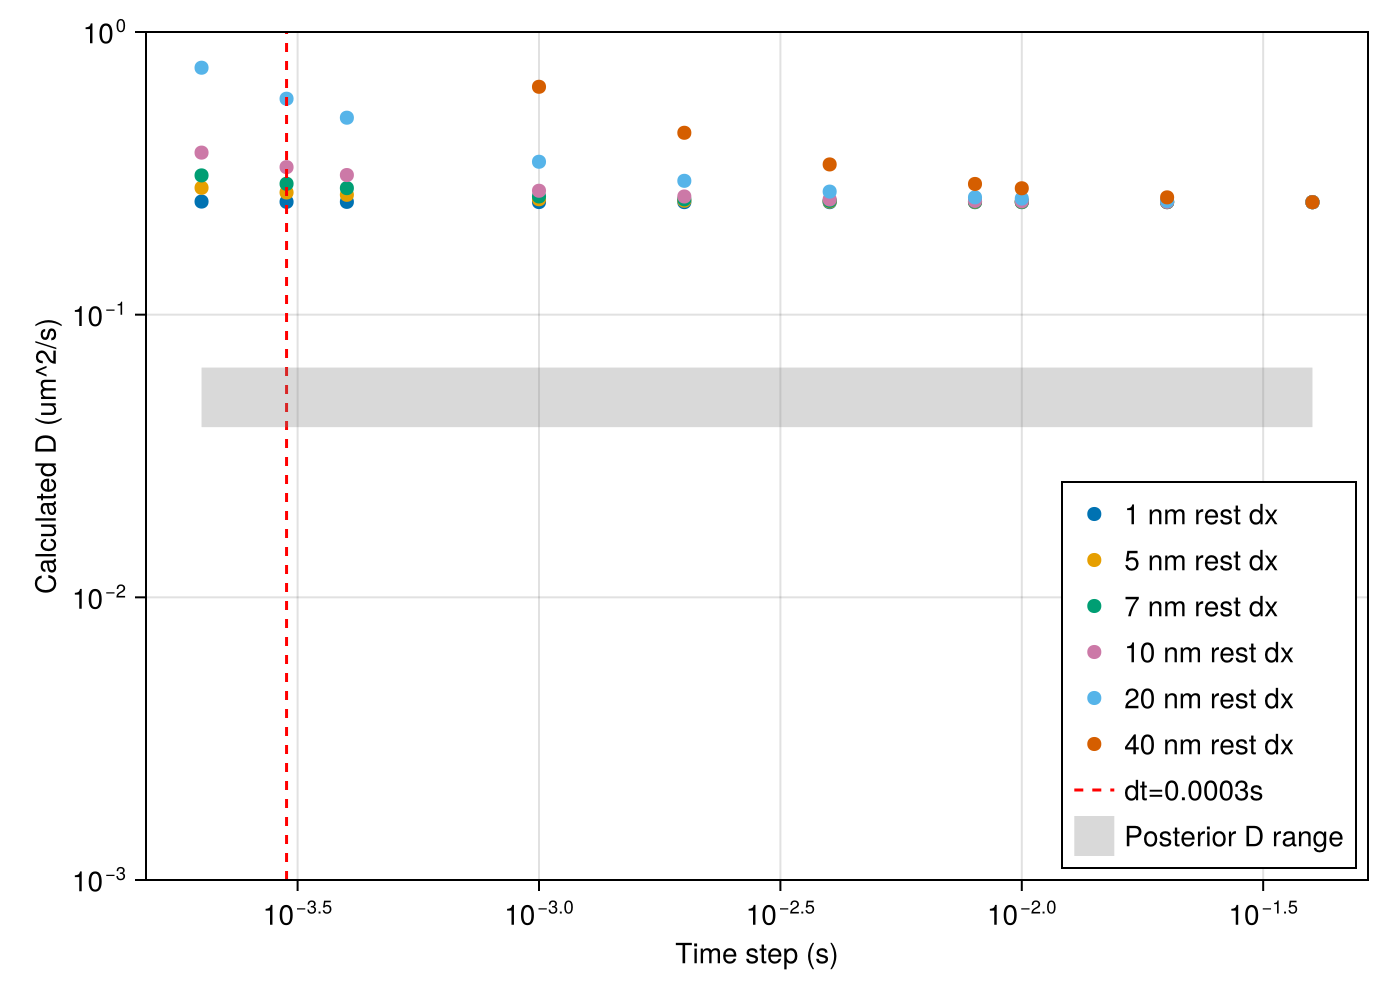

CairoMakie.Screen{IMAGE}


In [124]:
# 0.04 to 0.065
fig = Figure(size=(700,500))
ax = Axis(
    fig[1,1],
    xlabel = "Time step (s)",
    ylabel = "Calculated D (um^2/s)",
    xscale = log10,
    yscale= log10
)
for i in 1:length(dx_vals)
     scatter!(ax, dt, diff_coeffs[i, :], markersize=10, label="$(dx_vals[i]) nm rest dx")
end
vlines!(ax, 0.0003, color=:red, linestyle=:dash, label="dt=0.0003s")
band!(ax, dt, 0.04, 0.065, color=:gray, alpha=0.3, label="Posterior D range")
ylims!(ax, 10^-3, 1)
axislegend(ax, position=:rb)
display(fig)

### Assume 200nm step takes 5ms, so for faster frames it takes multiple "moving" steps

In [125]:
# Assume took some time to move
# The movement of 200nm seems to take two 250*20us steps = 5ms
move_time = 0.005

d = 0.2 # um
rest_dx = 0.01 #um
dx_vals = [1, 5, 7, 10, 20, 40] #nm
n_big_steps = 5
dims = 2
diff_coeffs = zeros((length(dx_vals), length(dt)))
# diff_coeffs = []
for (j, rest_dx_nm) in enumerate(dx_vals)
    rest_dx = rest_dx_nm / 1000
    for (i,dt_i) in enumerate(dt)
        println("\ndt: ", dt_i, " s")
        println("n_steps total: ", n_steps[i])
        println("move time: ", move_time, " s")
        timesteps_for_move = Int(ceil(move_time/dt_i))
        n_active_steps = timesteps_for_move * n_big_steps
        n_rest = Int(ceil(n_steps[i] - n_active_steps))
        println(n_active_steps, " steps taken, ", n_rest, " steps rest")
        d_step = d/timesteps_for_move
        println("d step: ", d_step, " um")
        displacements = vcat(fill(d_step^2, n_active_steps), fill(rest_dx^2, n_rest))
        # # print(displacements)
        msd = mean(displacements)
        println(2*dims*dt_i)
        diff_coeff = msd / (2*dims*dt_i)
        # # println("MSD: ", msd)
        println("Diff coeff: ", diff_coeff)
        # push!(diff_coeffs, diff_coeff)
        diff_coeffs[j, i] = diff_coeff
    end
end


dt: 0.04 s
n_steps total: 5.0
move time: 0.005 s
5 steps taken, 0 steps rest
d step: 0.2 um
0.16
Diff coeff: 0.25000000000000006

dt: 0.02 s
n_steps total: 10.0
move time: 0.005 s
5 steps taken, 5 steps rest
d step: 0.2 um
0.08
Diff coeff: 0.25000625000000004

dt: 0.01 s
n_steps total: 20.0
move time: 0.005 s
5 steps taken, 15 steps rest
d step: 0.2 um
0.04
Diff coeff: 0.25001875000000007

dt: 0.008 s
n_steps total: 25.0
move time: 0.005 s
5 steps taken, 20 steps rest
d step: 0.2 um
0.032
Diff coeff: 0.25002500000000005

dt: 0.004 s
n_steps total: 50.0
move time: 0.005 s
10 steps taken, 40 steps rest
d step: 0.1 um
0.016
Diff coeff: 0.12505000000000002

dt: 0.002 s
n_steps total: 100.0
move time: 0.005 s
15 steps taken, 85 steps rest
d step: 0.06666666666666667 um
0.008
Diff coeff: 0.08343958333333334

dt: 0.001 s
n_steps total: 200.0
move time: 0.005 s
25 steps taken, 175 steps rest
d step: 0.04 um
0.004
Diff coeff: 0.05021875000000001

dt: 0.0004 s
n_steps total: 500.0
move time: 0.

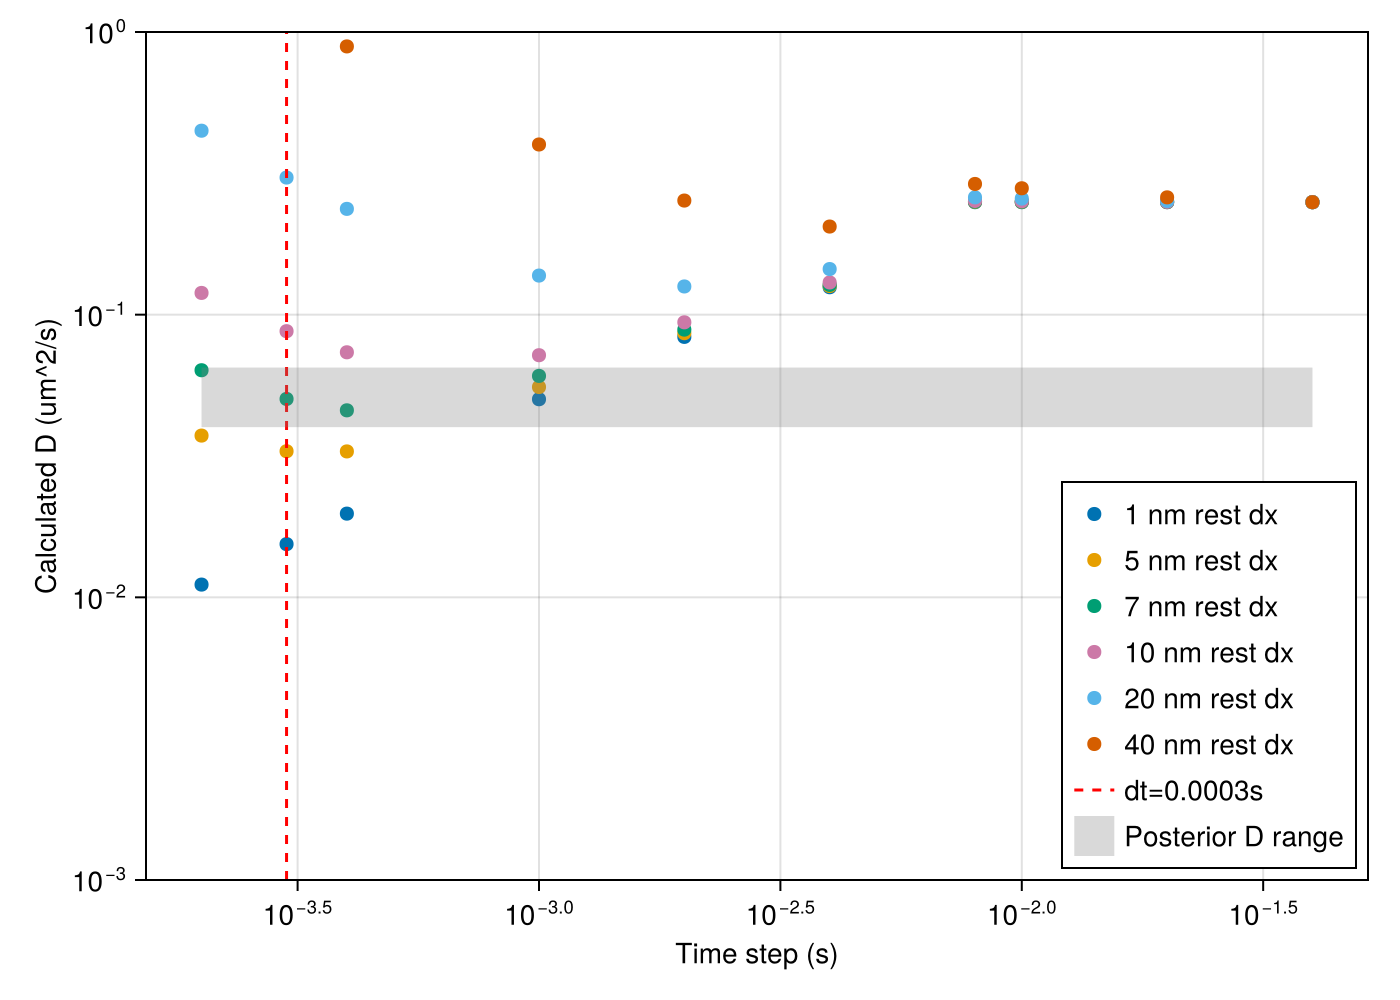

CairoMakie.Screen{IMAGE}


In [126]:
# 0.04 to 0.065
fig = Figure(size=(700,500))
ax = Axis(
    fig[1,1],
    xlabel = "Time step (s)",
    ylabel = "Calculated D (um^2/s)",
    xscale = log10,
    yscale= log10
)
for i in 1:length(dx_vals)
     scatter!(ax, dt, diff_coeffs[i, :], markersize=10, label="$(dx_vals[i]) nm rest dx")
end
vlines!(ax, 0.0003, color=:red, linestyle=:dash, label="dt=0.0003s")
band!(ax, dt, 0.04, 0.065, color=:gray, alpha=0.3, label="Posterior D range")
ylims!(ax, 10^-3, 1)
axislegend(ax, position=:rb)
display(fig)